In [123]:
import numpy as np
import matplotlib.pyplot as plt
from collections.abc import Iterable
from matplotlib.patches import Patch  # Per creare elementi di legenda personalizzati

In [2]:
!make clean
!make

rm -f test_for test_parallel_for_sure test_parallel_for_sure_n 
g++  -std=c++20 -pthread -Wall -I../../../../  test_for.cpp -o test_for
test_for.cpp: In function 'int main(int, char**)':
test_for.cpp:24:9: warning: unused variable 'n_blocchi' []8;;https://gcc.gnu.org/onlinedocs/gcc/Warning-Options.html#index-Wunused-variable-Wunused-variable]8;;]
   24 |     int n_blocchi = std::stoi(argv[5]); //numero blocchi in cui dividere range di for (utilizzato solo in parallel_for_sure_n)
      |         ^~~~~~~~~
g++  -std=c++20 -pthread -Wall -I../../../../  test_parallel_for_sure.cpp -o test_parallel_for_sure
test_parallel_for_sure.cpp: In function 'int main(int, char**)':
test_parallel_for_sure.cpp:24:9: warning: unused variable 'n_blocchi' []8;;https://gcc.gnu.org/onlinedocs/gcc/Warning-Options.html#index-Wunused-variable-Wunused-variable]8;;]
   24 |     int n_blocchi = std::stoi(argv[5]); //numero blocchi in cui dividere range di for (utilizzato solo in parallel_for_sure_n)
      

## confronto tra for / parallele_for_sure / parallel_for_sure_n

In [3]:
def run_test(test_name,n_runs = 200,n_elems = 1000,n_body_function = 100,n_threads = 1,size_queue = 32, n_blocchi = 10):
    if not isinstance(n_elems,Iterable):
        n_elems = [n_elems]
    if not isinstance(n_threads, Iterable):
        n_threads = [n_threads]

    results = []
    for threads in n_threads:
        for elem in n_elems:
            !sh risultati.sh $test_name $n_runs $elem $n_body_function $threads $size_queue $n_blocchi
            results.append(np.genfromtxt(test_name + ".txt",delimiter=',',dtype=int)[:-1])

    return results

## for / parallel_for_sure / parallel_for_sure_n

In [4]:
def plot(data_for, data_par_for, data_par_for_n,title):
    fig, ax = plt.subplots(figsize=[10, 10])
    
    boxs = []
    ticks = []
    boxs.append(data_for[0])
    ticks.append("for")
    for i in range(len(data_par_for)):
        boxs.append(data_par_for[i])
        boxs.append(data_par_for_n[i])
        ticks.append("p_for"+str(n_threads[i]))
        ticks.append("p_for_n"+str(n_threads[i]))

    
    bplot = ax.boxplot(boxs, showfliers=False, patch_artist=True)

    ax.set(ylabel = 'Microseconds')
    ax.set(title = title)
    ax.set_xticks(range(1,1+len(boxs)),ticks)
        

In [23]:
#set parameter
test_name = "test_" #inutile
n_runs = 50
n_elems = 1000
n_body_function = 10000
n_threads = [1,2,4,6,8]
size_queue = 64
n_blocchi = 8

In [24]:
# run test
dati_for = run_test("test_for",n_runs,n_elems,n_body_function,1,size_queue,n_blocchi)
dati_parallel_for_sure = run_test("test_parallel_for_sure",n_runs,n_elems,n_body_function,n_threads,size_queue,n_blocchi)
dati_parallel_for_sure_n = run_test("test_parallel_for_sure_n",n_runs,n_elems,n_body_function,n_threads,size_queue,n_blocchi)


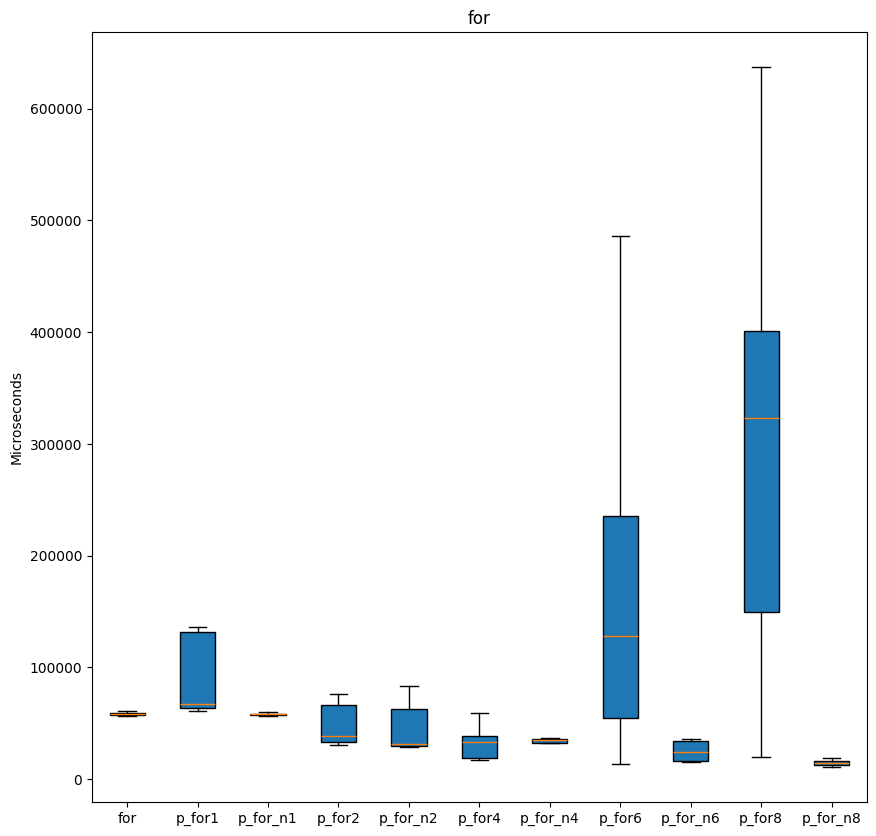

In [25]:
plot(dati_for, dati_parallel_for_sure, dati_parallel_for_sure_n,"for")

## for / parallel_for_sure_n

In [136]:
#confronto for-single thread con par_for_sure_n con n_thread variabile
def plot(data_for, data_par_for_n,title):
    fig, ax = plt.subplots(figsize=[10, 10])
    
    boxs = []
    ticks = []
    boxs.append(data_for[0])
    ticks.append("for")
    for i in range(len(data_par_for_n)):
        boxs.append(data_par_for_n[i])
        ticks.append("n_thread: "+str(n_threads[i]))

    
    bplot = ax.boxplot(boxs, showfliers=False, patch_artist=True)

    ax.set(ylabel = 'Microseconds')
    ax.set_title( title, loc = 'left')
    ax.set_xticks(range(1,1+len(boxs)),ticks)

    # Colora ogni box
    colors = ['orange'] + ['blue'] * (len(bplot['boxes']) - 1)
    for box, color in zip(bplot['boxes'], colors):
        box.set_facecolor(color)

    # Crea legenda con Patch
    legend_handles = [
        Patch(facecolor='orange', label='for'),
        Patch(facecolor='blue', label='parallel_for_sure_n')
    ]
    ax.legend(handles=legend_handles, loc='upper right')

    plt.figtext(0.48, 0.9, f"threadpool: size_queue({size_queue})\nsetup: range_for({n_elems}), unitary_operation_in_body_function({n_body_function*4}), n_blocchi({n_blocchi})", fontsize=9, 
            bbox=dict(facecolor='white', edgecolor='black'))

In [137]:
#set parameter
test_name = "test_" #inutile
n_runs = 50
n_elems = 1000
n_body_function = 10000
n_threads = [1,2,4,6,8]
size_queue = 64
n_blocchi = 8

In [138]:
# run test
dati_for = run_test("test_for",n_runs,n_elems,n_body_function,1,size_queue,n_blocchi)
dati_parallel_for_sure_n = run_test("test_parallel_for_sure_n",n_runs,n_elems,n_body_function,n_threads,size_queue,n_blocchi)

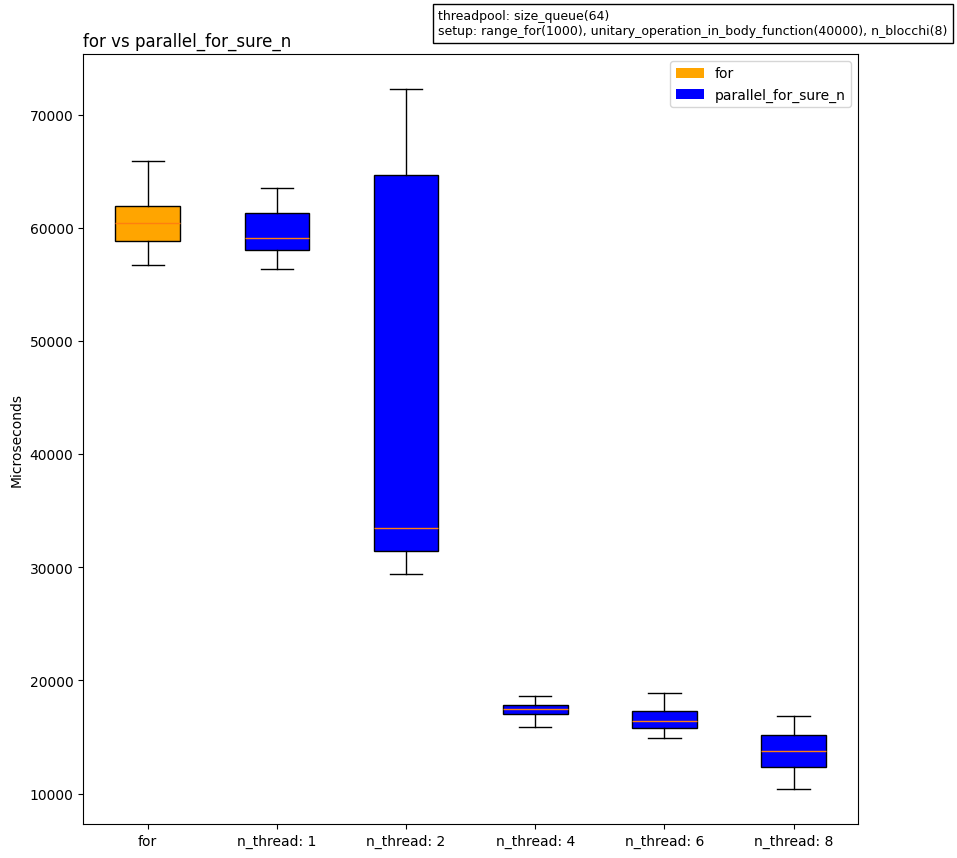

In [139]:
plot(dati_for, dati_parallel_for_sure_n,"for vs parallel_for_sure_n")

## prestazioni parallel_for_sure_n con n_blocchi (blocchi in cui si divide range di for) variabile

In [94]:
#set parameter
test_name = "test_" #inutile
n_runs = 100
n_elems = 200
n_body_function = 10000
n_threads = 8
size_queue = 64
n_blocchi = [1,2,4,8,10,20,40]

In [95]:
def run_test_n_blocchi(test_name,n_runs ,n_elems ,n_body_function ,n_threads ,size_queue , n_blocchi ):
    if not isinstance(n_elems,Iterable):
        n_elems = [n_elems]
    if not isinstance(n_blocchi, Iterable):
        n_blocchi = [n_blocchi]

    results = []
    for n_bloc in n_blocchi:
        for elem in n_elems:
            !sh risultati.sh $test_name $n_runs $elem $n_body_function $n_threads $size_queue $n_bloc
            results.append(np.genfromtxt(test_name + ".txt",delimiter=',',dtype=int)[:-1])

    return results

In [127]:
#confronto for-single thread con par_for_sure_n con n_blocchi variabile
def plot_n_blocchi(data_for, data_par_for_n,title):
    fig, ax = plt.subplots(figsize=[10, 8])
    
    boxs = []
    ticks = []
    boxs.append(data_for[0])
    ticks.append("for")
    for i in range(len(data_par_for_n)):
        boxs.append(data_par_for_n[i])
        ticks.append("n_blocchi: "+str(n_blocchi[i]))

    
    bplot = ax.boxplot(boxs, showfliers=False, patch_artist=True)

    ax.set(ylabel = 'Microseconds')
    ax.set_title( title, loc = 'left')
    ax.set_xticks(range(1,1+len(boxs)),ticks)

    # Colora ogni box
    colors = ['orange'] + ['blue'] * (len(bplot['boxes']) - 1)
    for box, color in zip(bplot['boxes'], colors):
        box.set_facecolor(color)

    # Crea legenda con Patch
    legend_handles = [
        Patch(facecolor='orange', label='for'),
        Patch(facecolor='blue', label='parallel_for_sure_n')
    ]
    ax.legend(handles=legend_handles, loc='upper right')

    plt.figtext(0.48, 0.9, f"threadpool: n_thread({n_threads}), size_queue({size_queue})\nsetup: range_for({n_elems}), unitary_operation_in_body_function({n_body_function*4})", fontsize=9, 
            bbox=dict(facecolor='white', edgecolor='black'))

In [134]:
# run test
dati_for = run_test_n_blocchi("test_for",n_runs,n_elems,n_body_function,1,size_queue,n_blocchi)
dati_parallel_for_sure_n = run_test_n_blocchi("test_parallel_for_sure_n",n_runs,n_elems,n_body_function,n_threads,size_queue,n_blocchi)

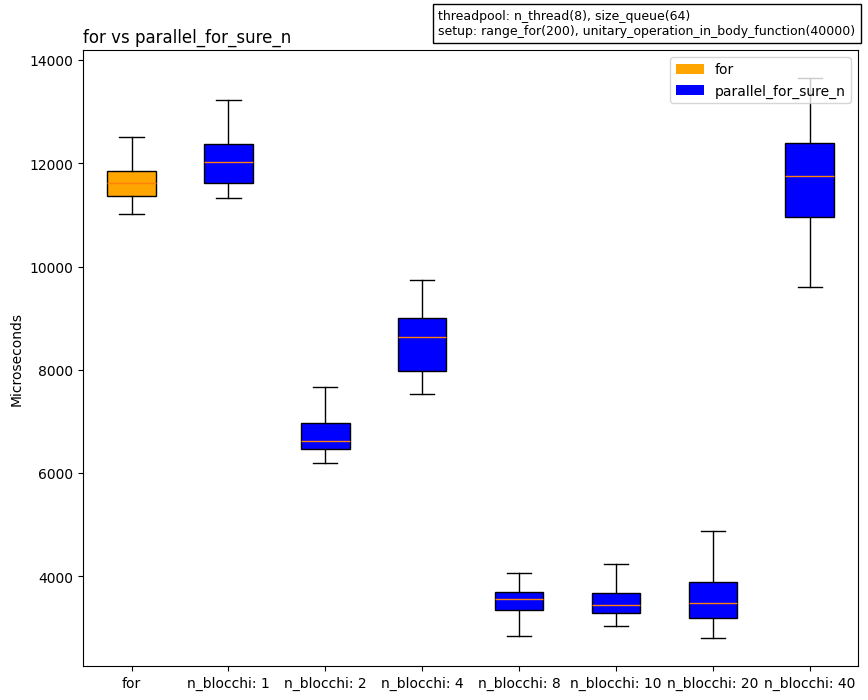

In [135]:
plot_n_blocchi(dati_for, dati_parallel_for_sure_n,"for vs parallel_for_sure_n")
